In [1]:
!pip install tensorboardX rdkit
!pip install rdkit-pypi

In [2]:
import os
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
#torch.manual_seed(8) # for reproduce


from sklearn.model_selection import LeaveOneOut
import time
from tqdm import tqdm
import numpy as np
import gc
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Posdoc/Native_AFP/code/')
sys.setrecursionlimit(50000)
import pickle
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
# from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True
import copy
import pandas as pd
#then import my own modules
from AttentiveFP import Fingerprint, Fingerprint_viz, save_smiles_dicts, get_smiles_dicts, get_smiles_array, moltosvg_highlight

/usr/local/lib/python3.11/dist-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [3]:
from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem import QED
from rdkit.Chem import rdMolDescriptors, MolSurf
from rdkit.Chem.Draw import SimilarityMaps
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
%matplotlib inline
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.cm as cm
import matplotlib
import seaborn as sns; sns.set_style("darkgrid")
from IPython.display import SVG, display
import sascorer
import itertools
from sklearn.metrics import r2_score
import scipy


import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
import pickle
import os
import time
from rdkit import Chem
from sklearn.model_selection import LeaveOneOut
from collections import defaultdict


device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
def prepare_model_and_data(raw_filename, target_name='Calx', targets=None, batch_size=50, epochs=800, p_dropout=0.1, fingerprint_dim=150, weight_decay=2, learning_rate=3, radius=3, T=2, per_target_output_units_num=1):
    if targets is None:
        targets = ['H3K4', 'H3K4ac', 'H3K4me1', 'H3K4me2', 'H3K4me3', 'H3K9me3', 'H3R2me2a', 'H3R2me2s']

    feature_filename = raw_filename.replace('.csv', '.pickle')
    filename = raw_filename.replace('.csv', '')
    prefix_filename = raw_filename.split('/')[-1].replace('.csv', '')
    smiles_targets_df = pd.read_csv(raw_filename)

    smilesList = smiles_targets_df.SMILES.values
    print("number of all smiles: ", len(smilesList))

    atom_num_dist = []
    remained_smiles = []
    canonical_smiles_list = []
    for smiles in smilesList:
        try:
            mol = Chem.MolFromSmiles(smiles)
            atom_num_dist.append(len(mol.GetAtoms()))
            remained_smiles.append(smiles)
            canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
        except:
            print(smiles)
            pass
    print("number of successfully processed smiles: ", len(remained_smiles))

    smiles_targets_df = smiles_targets_df[smiles_targets_df["SMILES"].isin(remained_smiles)]
    smiles_targets_df['cano_smiles'] = canonical_smiles_list

    start_time = str(time.ctime()).replace(':', '-').replace(' ', '_')
    output_units_num = len(targets) * per_target_output_units_num

    if os.path.isfile(feature_filename):
        feature_dicts = pickle.load(open(feature_filename, "rb"))
    else:
        feature_dicts = save_smiles_dicts(smilesList, filename)
    feature_dicts = get_smiles_dicts(smilesList)

    remained_df = smiles_targets_df[smiles_targets_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]

    x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array([canonical_smiles_list[0]], feature_dicts)
    num_atom_features = x_atom.shape[-1]
    num_bond_features = x_bonds.shape[-1]

    loss_function = nn.MSELoss()
    model = Fingerprint(radius, T, num_atom_features, num_bond_features, fingerprint_dim, output_units_num, p_dropout)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)

    model_parameters = filter(lambda p: p.requires_grad, model.parameters())
    params = sum([np.prod(p.size()) for p in model_parameters])
    #print(params)
    #for name, param in model.named_parameters():
     #   if param.requires_grad:
      #      print(name, param.data.shape)

    return model, optimizer, loss_function, remained_df, targets, feature_dicts




In [5]:
def train(model, dataset, optimizer, loss_function, epoch, batch_size, targets, feature_dicts, ratio_list):
    model.train()
    #np.random.seed(epoch)
    
    if len(dataset) <= batch_size:
        batch_list = [dataset.index]
    else:
        valList = np.arange(0, dataset.shape[0])
        np.random.shuffle(valList)
        batch_list = [valList[i:i+batch_size] for i in range(0, dataset.shape[0], batch_size)]
    
    device = next(model.parameters()).device
    total_loss = 0
    
    for counter, batch in enumerate(batch_list):
        batch_df = dataset.loc[batch, :]
        smiles_list = batch_df.cano_smiles.values
        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(smiles_list, feature_dicts)
        
        x_atom = torch.Tensor(x_atom).to(device)
        x_bonds = torch.Tensor(x_bonds).to(device)
        x_atom_index = torch.LongTensor(x_atom_index).to(device)
        x_bond_index = torch.LongTensor(x_bond_index).to(device)
        x_mask = torch.Tensor(x_mask).to(device)
        
        atoms_prediction, mol_prediction = model(x_atom, x_bonds, x_atom_index, x_bond_index, x_mask)
        
        optimizer.zero_grad()
        loss = 0.0
        
        for i, target in enumerate(targets):
            y_pred = mol_prediction[:, i]
            y_val = torch.Tensor(batch_df[target].values).squeeze().to(device)
            target_loss = loss_function(y_pred, y_val) * (ratio_list[i] ** 2)
            loss += target_loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(batch_list)


def eval(model, dataset, targets, feature_dicts, batch_size):
    model.eval()
    
    eval_MAE_list = {target: [] for target in targets}
    eval_MSE_list = {target: [] for target in targets}
    y_val_list = {target: [] for target in targets}
    y_pred_list = {target: [] for target in targets}
    smiles_list = []
    
    if len(dataset) <= batch_size:
        batch_list = [dataset.index]
    else:
        valList = np.arange(0, dataset.shape[0])
        batch_list = [valList[i:i+batch_size] for i in range(0, dataset.shape[0], batch_size)]
    
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for batch in batch_list:
            batch_df = dataset.loc[batch, :]
            batch_smiles = batch_df.cano_smiles.values
            smiles_list.extend(batch_smiles)
            
            x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(batch_smiles, feature_dicts)
            
            x_atom = torch.Tensor(x_atom).to(device)
            x_bonds = torch.Tensor(x_bonds).to(device)
            x_atom_index = torch.LongTensor(x_atom_index).to(device)
            x_bond_index = torch.LongTensor(x_bond_index).to(device)
            x_mask = torch.Tensor(x_mask).to(device)
            
            atoms_prediction, mol_prediction = model(x_atom, x_bonds, x_atom_index, x_bond_index, x_mask)
            
            for i, target in enumerate(targets):
                y_pred = mol_prediction[:, i].view(-1, 1)
                y_val = torch.Tensor(batch_df[target].values.reshape(-1, 1)).to(device)
                
                MAE = F.l1_loss(y_pred, y_val, reduction='none')
                MSE = F.mse_loss(y_pred, y_val, reduction='none')
                
                y_pred_list[target].extend(y_pred.cpu().numpy().flatten())
                y_val_list[target].extend(y_val.cpu().numpy().flatten())
                
                eval_MAE_list[target].extend(MAE.cpu().numpy().flatten())
                eval_MSE_list[target].extend(MSE.cpu().numpy().flatten())
    
    eval_MAE = np.array([np.mean(eval_MAE_list[target]) for target in targets])
    eval_MSE = np.array([np.mean(eval_MSE_list[target]) for target in targets])
    
    return eval_MAE, eval_MSE, y_pred_list, y_val_list, smiles_list





from collections import defaultdict
from sklearn.model_selection import LeaveOneOut

def train_and_evaluate(model, remained_df, targets, feature_dicts, optimizer, loss_function, batch_size, num_epochs, patience=30, min_delta=0.001, prefix_filename='', start_time=''):
    best_param = {"train_epoch": 0, "test_epoch": 0, "train_MSE": float('inf'), "test_MSE": float('inf')}
    stats_list = []
    ratio_list = [1.0] * len(targets)
    loo = LeaveOneOut()
    fold_results = []
    best_fold_results = []
    regression = {}

    train_predictions = {target: [] for target in targets}
    train_actuals = {target: [] for target in targets}
    test_predictions = {target: [] for target in targets}
    test_actuals = {target: [] for target in targets}
    
    initial_state = {k: v.clone() for k, v in model.state_dict().items()}
    for fold, (train_index, test_index) in enumerate(loo.split(remained_df)):
        print(f"\nFold {fold + 1}/{len(remained_df)}")

        # Reset model parameters to initial state
        model.load_state_dict(initial_state)
        
        # Reset optimizer state
        optimizer.state = defaultdict(dict)

        train_df = remained_df.iloc[train_index].copy()
        test_df = remained_df.iloc[test_index].copy()
        current_smile = test_df['Host'].values[0]

        best_train_mse = float('inf')
        best_model_state = None
        best_val_mse = float('inf')
        epochs_no_improve = 0
        best_train_metrics = None

        for epoch in range(num_epochs):
            train_loss = train(model, train_df, optimizer, loss_function, epoch, batch_size, targets, feature_dicts, ratio_list)
            train_MAE, train_MSE, train_pred, train_actual, _ = eval(model, train_df, targets, feature_dicts, batch_size)

            if train_MSE.mean() < best_train_mse:
                best_train_mse = train_MSE.mean()
                best_model_state = model.state_dict()
                best_param["train_epoch"] = epoch
                best_param["train_MSE"] = train_MSE.mean()
                best_train_metrics = (train_MAE, train_MSE, train_pred, train_actual)

            # Evaluate on validation set
            val_MAE, val_MSE, val_pred, val_actual, _ = eval(model, test_df, targets, feature_dicts, batch_size)

            if val_MSE.mean() < best_val_mse - min_delta:
                best_val_mse = val_MSE.mean()
                epochs_no_improve = 0
                best_model_state = model.state_dict()
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

        # Load the best model state for this fold
        model.load_state_dict(best_model_state)

        # Use the best train metrics
        train_MAE, train_MSE, train_pred, train_actual = best_train_metrics

        # Save train metrics only for the best epoch
        for target in targets:
            train_predictions[target].extend(train_pred[target])
            train_actuals[target].extend(train_actual[target])

        # Evaluate on test set only once, after training is complete
        test_MAE, test_MSE, test_pred, test_actual, test_smiles = eval(model, test_df, targets, feature_dicts, batch_size)

        for target in targets:
            test_predictions[target].extend(test_pred[target])
            test_actuals[target].extend(test_actual[target])

        best_fold_results.append((train_MAE.mean(), train_MSE.mean(), test_MAE.mean(), test_MSE.mean()))
        
        # Create the dictionary entry for the current test row
        regression[current_smile] = {}
        for target in targets:
            regression[current_smile][target] = {
                "predicted": test_pred[target][0],
                "actual": test_actual[target][0]
            }

        print(f"\nTest point details for Fold {fold + 1}:")
        print(f"SMILES: {current_smile}")
        for target in targets:
            print(f"{target}:")
            print(f" Actual value: {test_actual[target][0]:.4f}")
            print(f" Predicted value: {test_pred[target][0]:.4f}")

        fold_results.append({
            'fold': fold + 1,
            'smiles': current_smile,
            'actual_values': {target: test_actual[target][0] for target in targets},
            'predicted_values': {target: test_pred[target][0] for target in targets}
        })

    overall_train_mae = np.mean([res[0] for res in best_fold_results])
    overall_train_mse = np.mean([res[1] for res in best_fold_results])
    overall_test_mae = np.mean([res[2] for res in best_fold_results])
    overall_test_mse = np.mean([res[3] for res in best_fold_results])

    print("\nFinal Results:")
    print(f"Overall Training MAE: {overall_train_mae:.4f}")
    print(f"Overall Training MSE: {overall_train_mse:.4f}")
    print(f"Overall Test MAE: {overall_test_mae:.4f}")
    print(f"Overall Test MSE: {overall_test_mse:.4f}")

    return overall_train_mae, overall_train_mse, overall_test_mae, overall_test_mse, fold_results, regression, train_predictions, train_actuals, test_predictions, test_actuals

In [6]:

model, optimizer, loss_function, remained_df, targets, feature_dicts = prepare_model_and_data('/notebooks/data/cal_abs.csv')
"""overall_train_mae, overall_train_mse, overall_valid_mae, overall_valid_mse, fold_results, regression = train_and_evaluate(
    model, 
    remained_df, 
    targets, 
    feature_dicts, 
    optimizer, 
    loss_function, 
    batch_size=50, 
    num_epochs=5, 
    prefix_filename='your_prefix', 
    start_time='your_start_time',
  # Ensure scaler is passed here
)"""


results = train_and_evaluate(model, remained_df, targets, feature_dicts, optimizer, loss_function, batch_size=50, num_epochs=800)
train_predictions, train_actuals, test_predictions, test_actuals = results[-4:]


                                                                                 

number of all smiles:  40
number of successfully processed smiles:  40

Fold 1/40
Early stopping at epoch 253

Test point details for Fold 1:
SMILES: AP8
H3K4:
 Actual value: -1.3093
 Predicted value: -0.8585
H3K4ac:
 Actual value: 0.0000
 Predicted value: 0.3711
H3K4me1:
 Actual value: -3.0791
 Predicted value: -2.6270
H3K4me2:
 Actual value: -5.1850
 Predicted value: -5.2057
H3K4me3:
 Actual value: -5.0207
 Predicted value: -4.9247
H3K9me3:
 Actual value: -3.7723
 Predicted value: -3.9387
H3R2me2a:
 Actual value: -4.1997
 Predicted value: -4.0060
H3R2me2s:
 Actual value: -2.6037
 Predicted value: -2.1714

Fold 2/40
Early stopping at epoch 33

Test point details for Fold 2:
SMILES: AH4
H3K4:
 Actual value: -0.1165
 Predicted value: 1.0019
H3K4ac:
 Actual value: 1.4110
 Predicted value: 1.5371
H3K4me1:
 Actual value: -2.2073
 Predicted value: -0.0391
H3K4me2:
 Actual value: -5.2983
 Predicted value: -1.5030
H3K4me3:
 Actual value: -3.5066
 Predicted value: -1.8015
H3K9me3:
 Actual valu

In [7]:
import numpy as np
from sklearn.metrics import r2_score

def calculate_overall_r2(data):
    all_predicted = []
    all_actual = []

    for compound in data.values():
        for histone_mod in compound.values():
            all_predicted.append(histone_mod['predicted'])
            all_actual.append(histone_mod['actual'])

    all_predicted = np.array(all_predicted)
    all_actual = np.array(all_actual)

    overall_r2 = r2_score(all_actual, all_predicted)
    return overall_r2


overall_r2 = calculate_overall_r2(results[5])
print(f"Overall R² score: {overall_r2:.4f}")


Overall R² score: 0.3906


In [21]:
import pickle

dictionary_to_save = results[5]

file_name = "./results_dictionary.pkl"

with open(file_name, "wb") as file:
    pickle.dump(dictionary_to_save, file)

print(f"Dictionary saved as {file_name}")

Dictionary saved as ./results_dictionary.pkl


Debug: H3K4 - Train Predictions: 1560, Train Actuals: 1560
Debug: H3K4 - Test Predictions: 40, Test Actuals: 40


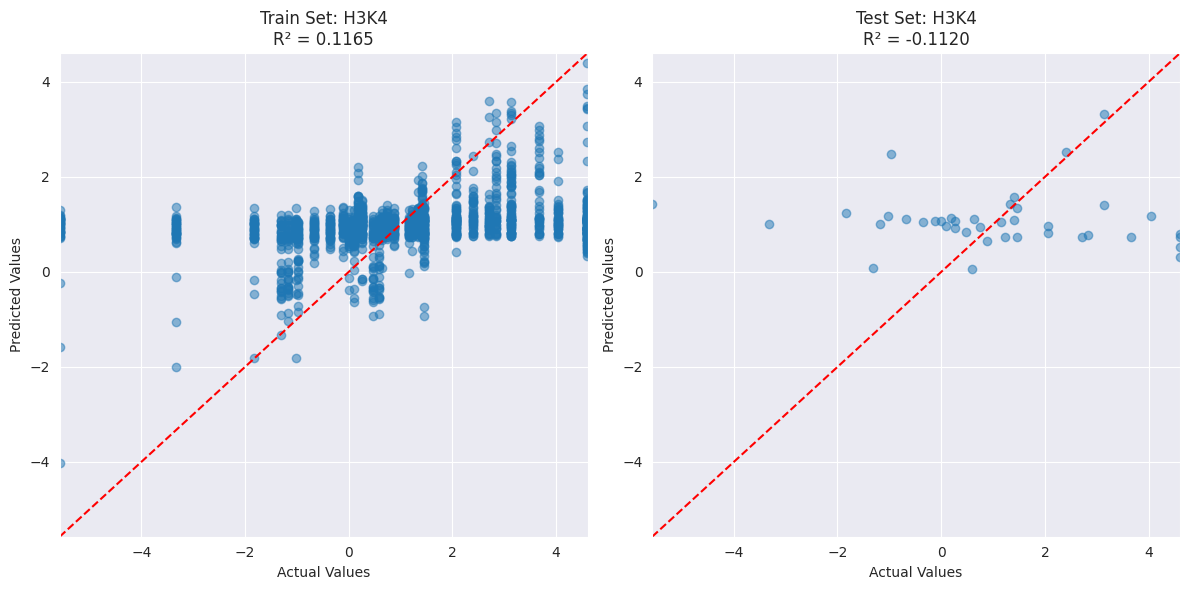

Debug: H3K4ac - Train Predictions: 1560, Train Actuals: 1560
Debug: H3K4ac - Test Predictions: 40, Test Actuals: 40


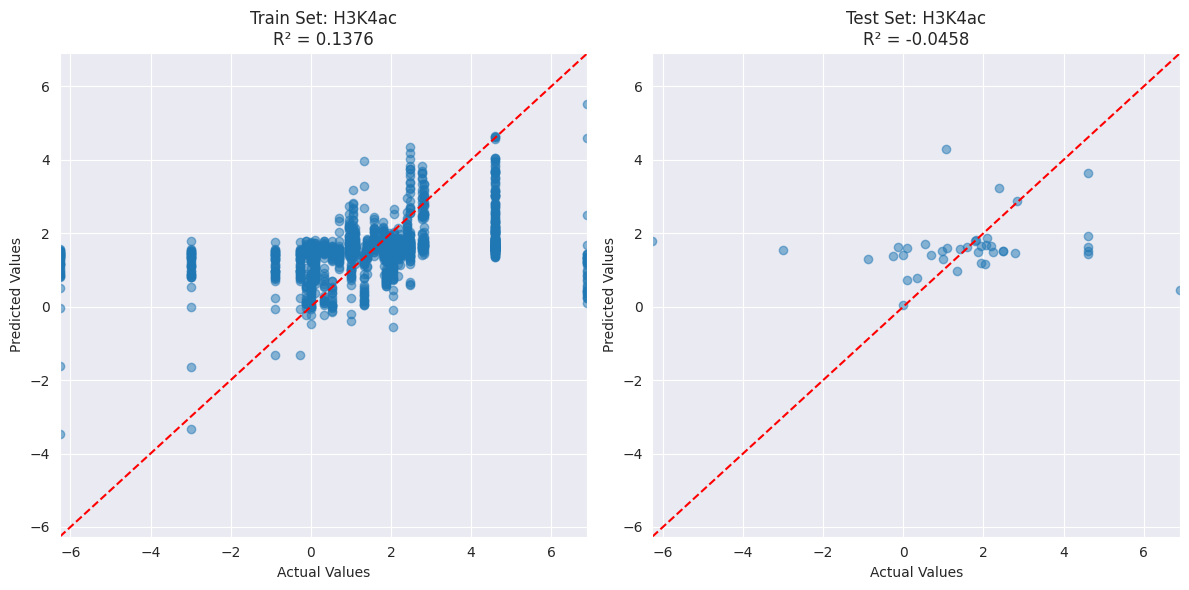

Debug: H3K4me1 - Train Predictions: 1560, Train Actuals: 1560
Debug: H3K4me1 - Test Predictions: 40, Test Actuals: 40


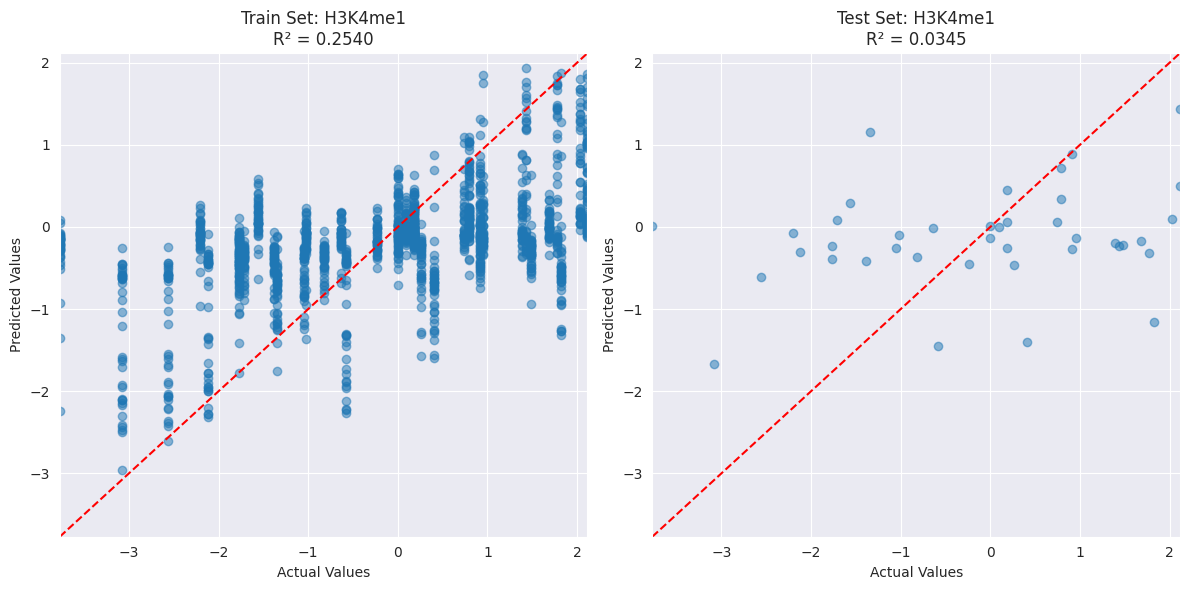

Debug: H3K4me2 - Train Predictions: 1560, Train Actuals: 1560
Debug: H3K4me2 - Test Predictions: 40, Test Actuals: 40


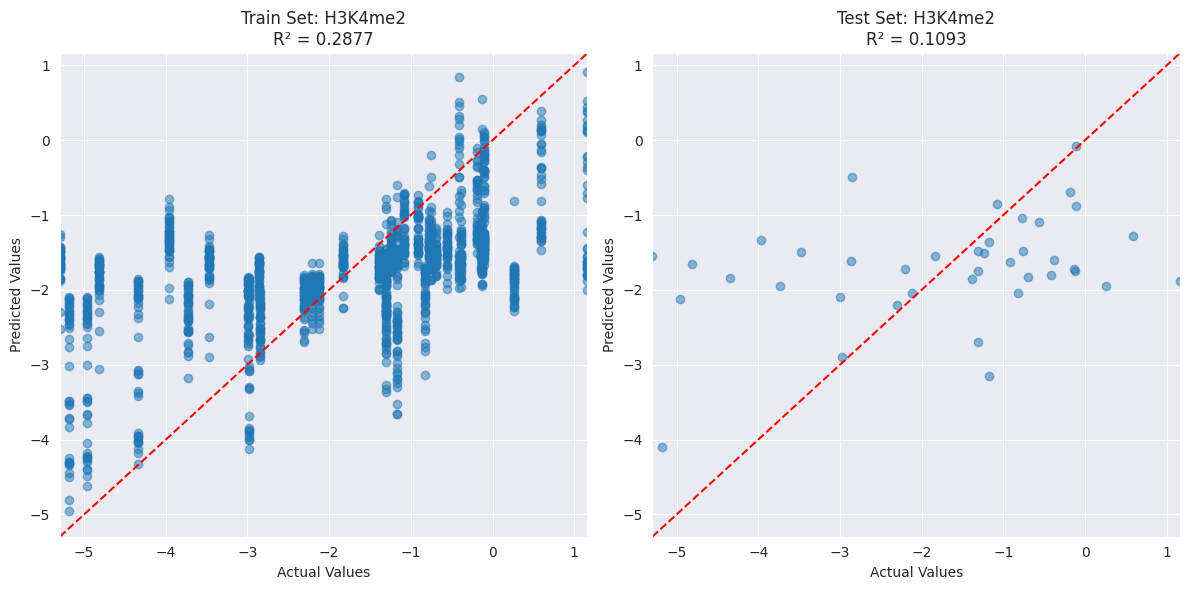

Debug: H3K4me3 - Train Predictions: 1560, Train Actuals: 1560
Debug: H3K4me3 - Test Predictions: 40, Test Actuals: 40


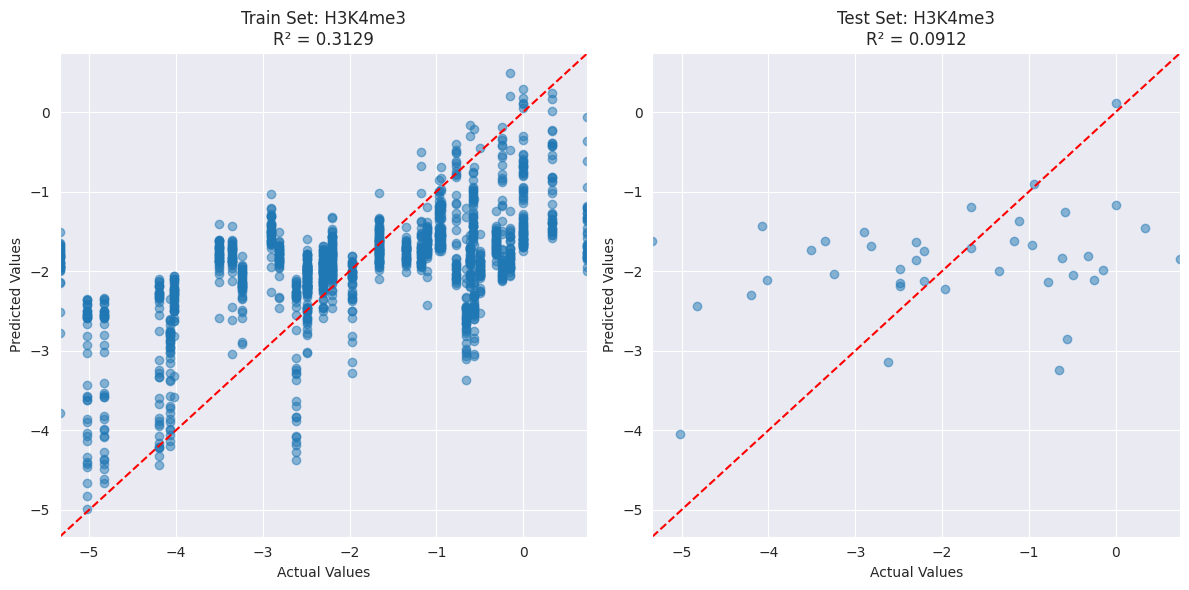

Debug: H3K9me3 - Train Predictions: 1560, Train Actuals: 1560
Debug: H3K9me3 - Test Predictions: 40, Test Actuals: 40


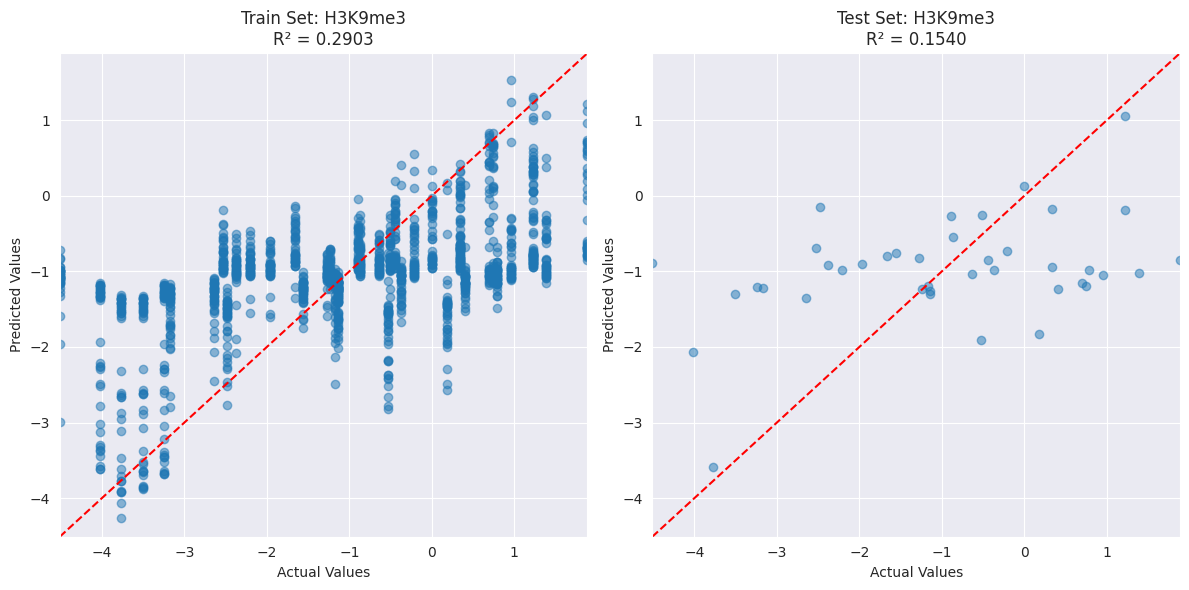

Debug: H3R2me2a - Train Predictions: 1560, Train Actuals: 1560
Debug: H3R2me2a - Test Predictions: 40, Test Actuals: 40


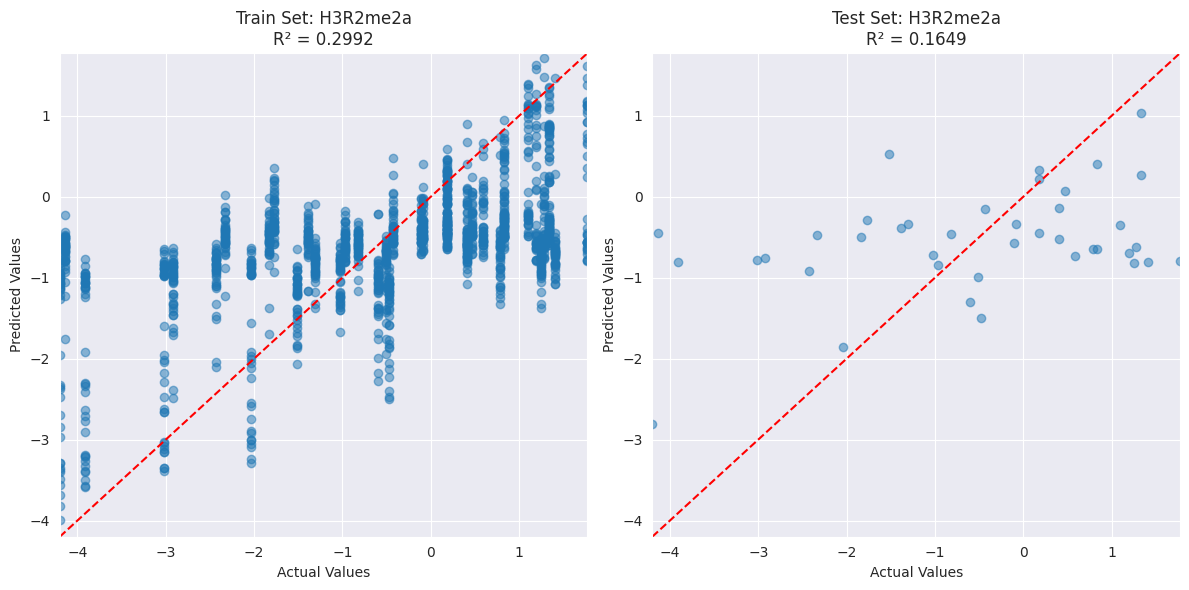

Debug: H3R2me2s - Train Predictions: 1560, Train Actuals: 1560
Debug: H3R2me2s - Test Predictions: 40, Test Actuals: 40


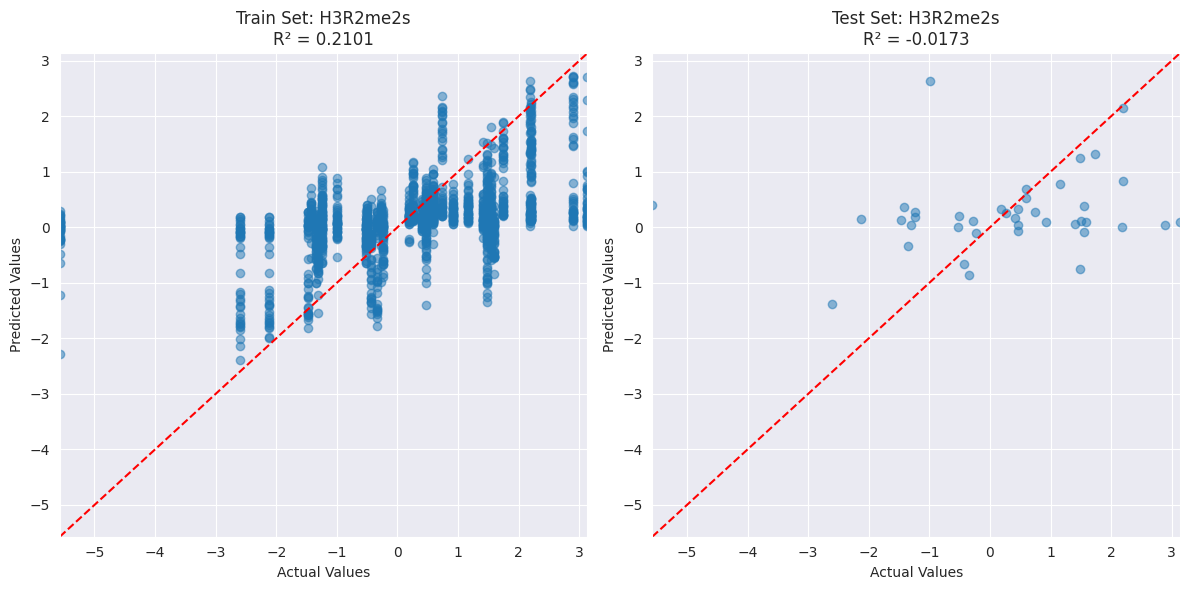

In [17]:
def plot_predictions_vs_actuals(train_predictions, train_actuals, test_predictions, test_actuals, targets):
    for target in targets:
        print(f"Debug: {target} - Train Predictions: {len(train_predictions[target])}, Train Actuals: {len(train_actuals[target])}")
        print(f"Debug: {target} - Test Predictions: {len(test_predictions[target])}, Test Actuals: {len(test_actuals[target])}")

        plt.figure(figsize=(12, 6))

        # Determine overall min and max for both train and test sets
        overall_min = min(min(train_actuals[target]), min(test_actuals[target]))
        overall_max = max(max(train_actuals[target]), max(test_actuals[target]))

        # Plot for training serest
        plt.subplot(1, 2, 1)
        plt.scatter(train_actuals[target], train_predictions[target], alpha=0.5)
        plt.plot([overall_min, overall_max], [overall_min, overall_max], 'r--')
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.xlim(overall_min, overall_max)
        plt.ylim(overall_min, overall_max)
        
        # Calculate and add R² for training set
        r2_train = r2_score(train_actuals[target], train_predictions[target])
        plt.title(f'Train Set: {target}\nR² = {r2_train:.4f}')
        plt.grid(True)

        # Plot for test set
        plt.subplot(1, 2, 2)
        plt.scatter(test_actuals[target], test_predictions[target], alpha=0.5)
        plt.plot([overall_min, overall_max], [overall_min, overall_max], 'r--')
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.xlim(overall_min, overall_max)
        plt.ylim(overall_min, overall_max)
        
        # Calculate and add R² for test set
        r2_test = r2_score(test_actuals[target], test_predictions[target])
        plt.title(f'Test Set: {target}\nR² = {r2_test:.4f}')
        plt.grid(True)

        plt.tight_layout()
        plt.show()

# Ensure these variables are correctly defined before calling the function
plot_predictions_vs_actuals(train_predictions, train_actuals, test_predictions, test_actuals, targets)


